# 03 — Window Comparison: The Bias-Variance Trade-off

**Lesson:** Short windows react fast but are noisy; long windows are stable but stale during regime changes. No single window is best — a monitoring system should expose multiple.

This notebook answers: *what happens when we change the look-back window, and why does it matter?*

## ⚙️ Parameters

Change these and re-run all cells to see the effect.

In [1]:
# ⚙️ Parameters
TICKER = "SPY"
START_DATE = "2018-01-01"
END_DATE = None
WINDOWS = [60, 252, 504]
CONFIDENCE = 0.95

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle

from src.rolling import rolling_var
from yfinance_helpers import download_close_prices, prepare_returns

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"

---

## Part A: Three windows overlaid

The same asset, same confidence, three different look-back windows.

In [3]:
prices = download_close_prices(TICKER, start=START_DATE, end=END_DATE)
returns = prepare_returns(prices)

results = {}
for w in WINDOWS:
    results[w] = rolling_var(returns, window=w, confidence=CONFIDENCE)
    print(f"{w:>4}d: {len(results[w])} estimates, breach rate = {results[w]['Breach'].mean():.3%}")

Prepared 2143 daily returns (2018-01-03 to 2026-07-15) from 2144 price observations.


  60d: 2083 estimates, breach rate = 7.201%


 252d: 1891 estimates, breach rate = 4.759%


 504d: 1639 estimates, breach rate = 4.759%


### The full picture

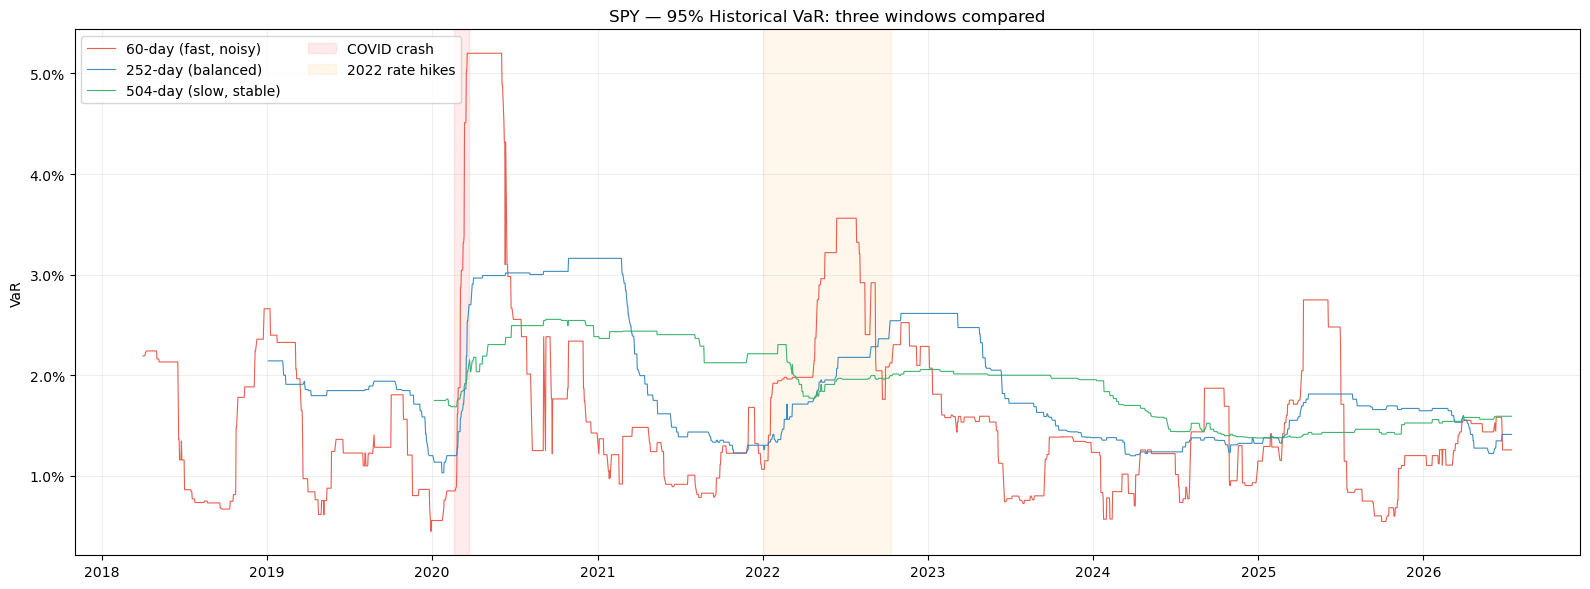

In [4]:
colors = {60: "#e74c3c", 252: "#2980b9", 504: "#27ae60"}
labels = {60: "60-day (fast, noisy)", 252: "252-day (balanced)", 504: "504-day (slow, stable)"}

fig, ax = plt.subplots(figsize=(16, 6))

for w in WINDOWS:
    ax.plot(results[w].index, results[w]["VaR"],
            color=colors[w], linewidth=0.8, alpha=0.9, label=labels[w])

# Crisis annotations
ax.axvspan(pd.Timestamp("2020-02-19"), pd.Timestamp("2020-03-23"),
           alpha=0.08, color="red", label="COVID crash")
ax.axvspan(pd.Timestamp("2022-01-03"), pd.Timestamp("2022-10-12"),
           alpha=0.08, color="orange", label="2022 rate hikes")

ax.set_ylabel("VaR")
ax.set_title(f"{TICKER} — {CONFIDENCE:.0%} Historical VaR: three windows compared")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.legend(loc="upper left", ncol=2)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### What you should see

- **60-day (red):** Jumpy — reacts within days to volatility spikes, but also bounces around during calm periods.
- **504-day (green):** Nearly flat — takes months to reflect a crisis, and stays elevated long after it passes.
- **252-day (blue):** Between the two — faster than 504, less noisy than 60.

During COVID: red spikes first, blue follows weeks later, green barely moves until the crash fills its window.

---

## Part B: The five investigation questions

### 1. Which window reacts fastest after a volatility spike?

Zoom into the COVID crash period. Watch which line moves first.

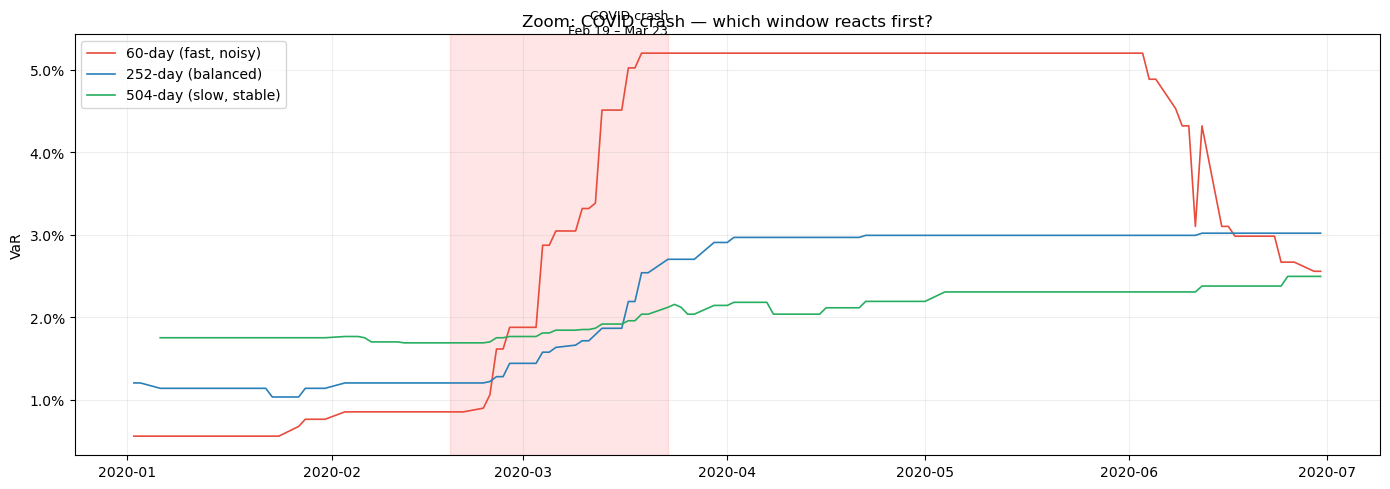

  60d window: VaR crossed 3% on 2020-03-06 — 16 days after crash began
 252d window: VaR crossed 3% on 2020-06-12 — 114 days after crash began


In [5]:
fig, ax = plt.subplots(figsize=(14, 5))

start_zoom = pd.Timestamp("2020-01-02")
end_zoom = pd.Timestamp("2020-06-30")

for w in WINDOWS:
    mask = (results[w].index >= start_zoom) & (results[w].index <= end_zoom)
    ax.plot(results[w].index[mask], results[w]["VaR"][mask],
            color=colors[w], linewidth=1.2, label=labels[w])

ax.axvspan(pd.Timestamp("2020-02-19"), pd.Timestamp("2020-03-23"),
           alpha=0.1, color="red")
ax.annotate("COVID crash\nFeb 19 – Mar 23",
            xy=(pd.Timestamp("2020-03-23"), ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 0.06),
            fontsize=9, ha="right")

ax.set_ylabel("VaR")
ax.set_title(f"Zoom: COVID crash — which window reacts first?")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.legend(loc="upper left")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Find when each window first crosses 3% VaR after the crash starts
crash_start = pd.Timestamp("2020-02-19")
for w in WINDOWS:
    post_crash = results[w].loc[crash_start:]
    spike_day = post_crash[post_crash["VaR"] > 0.03].index
    if len(spike_day) > 0:
        days_to_spike = (spike_day[0] - crash_start).days
        print(f"{w:>4}d window: VaR crossed 3% on {spike_day[0].date()} — {days_to_spike} days after crash began")

### 2. Which window is most stable?

Measured by how much the VaR estimate varies day to day.

In [6]:
print(f"{'Window':<10} {'Mean VaR':>10} {'Std VaR':>10} {'Coef of var':>12}")
print("-" * 44)
for w in WINDOWS:
    mean_var = results[w]["VaR"].mean()
    std_var = results[w]["VaR"].std()
    cv = std_var / mean_var
    print(f"{w:>4}d     {mean_var:>9.3%}  {std_var:>9.3%}  {cv:>11.2f}")

Window       Mean VaR    Std VaR  Coef of var
--------------------------------------------
  60d        1.619%     0.899%         0.56
 252d        1.874%     0.581%         0.31
 504d        1.904%     0.368%         0.19


### 3. When does the short window generate noisy signals?

Zoom into a calm period. The 60-day VaR bounces around while the 504-day is nearly flat.

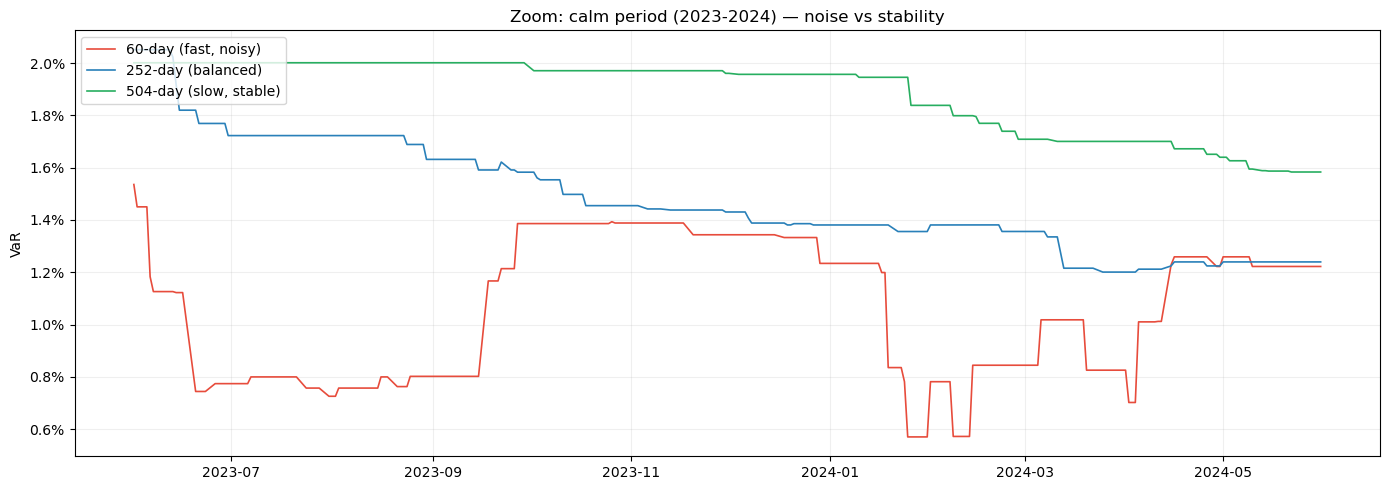

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

start_calm = pd.Timestamp("2023-06-01")
end_calm = pd.Timestamp("2024-06-01")

for w in WINDOWS:
    mask = (results[w].index >= start_calm) & (results[w].index <= end_calm)
    ax.plot(results[w].index[mask], results[w]["VaR"][mask],
            color=colors[w], linewidth=1.2, label=labels[w])

ax.set_ylabel("VaR")
ax.set_title(f"Zoom: calm period (2023-2024) — noise vs stability")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.legend(loc="upper left")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### 4. How long does the 252-day window take to reflect a crisis?

The 252-day window needs crash days to accumulate before VaR rises meaningfully.

In [8]:
w = 252
crash_start = pd.Timestamp("2020-02-19")
post_crash = results[w].loc[crash_start:]

pre_crash_var = results[w].loc[:crash_start, "VaR"].iloc[-1]
doubling_threshold = pre_crash_var * 2

doubling_day = post_crash[post_crash["VaR"] > doubling_threshold].index

print(f"Pre-crash 252d VaR (Feb 19, 2020): {pre_crash_var:.4%}")
if len(doubling_day) > 0:
    days = (doubling_day[0] - crash_start).days
    print(f"VaR doubled to >{doubling_threshold:.4%} on {doubling_day[0].date()}")
    print(f"That's {days} calendar days ({days * 5 // 7:.0f} trading days) after the crash began.")
    print(f"\nInterpretation: the 252d window needs ~{days * 5 // 7:.0f} trading days of high")
    print(f"volatility before the old calm days are diluted enough for VaR to reflect the new regime.")
else:
    print("VaR never doubled. The crash wasn't severe enough relative to pre-crash vol.")

Pre-crash 252d VaR (Feb 19, 2020): 1.2020%
VaR doubled to >2.4041% on 2020-03-19
That's 29 calendar days (20 trading days) after the crash began.

Interpretation: the 252d window needs ~20 trading days of high
volatility before the old calm days are diluted enough for VaR to reflect the new regime.


### 5. Does the long window remain elevated after the crisis passes?

The 504-day window carries crisis memory for two full years after the event.

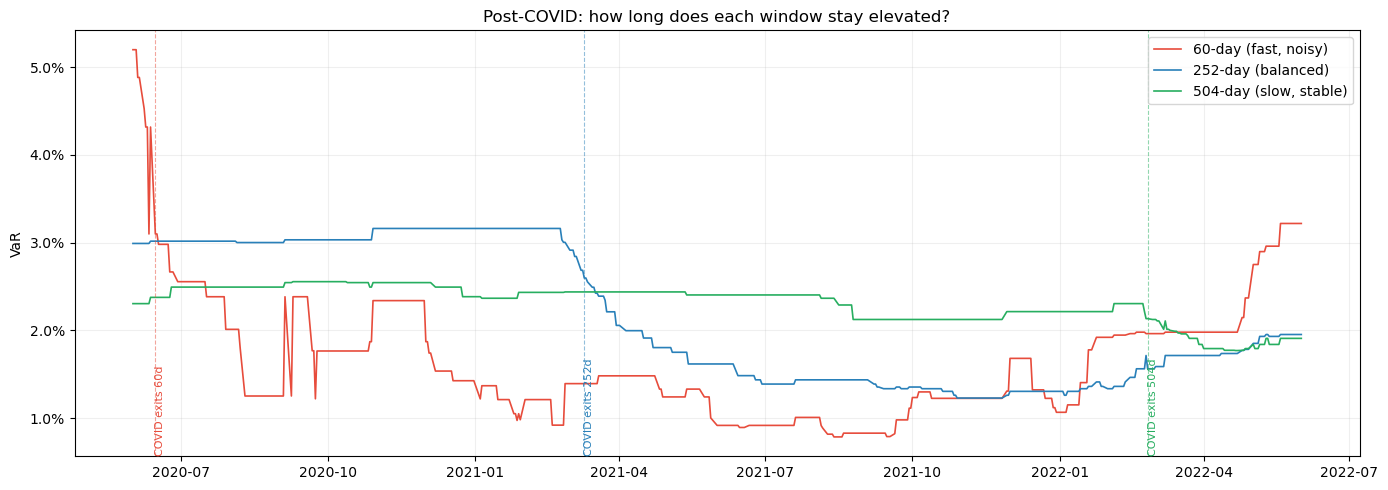

VaR in late 2021 (well after COVID crash, before 2022 rate hikes):
    60d: 1.6814%
   252d: 1.3053%
   504d: 2.2145%


In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

start_post = pd.Timestamp("2020-06-01")
end_post = pd.Timestamp("2022-06-01")

for w in WINDOWS:
    mask = (results[w].index >= start_post) & (results[w].index <= end_post)
    ax.plot(results[w].index[mask], results[w]["VaR"][mask],
            color=colors[w], linewidth=1.2, label=labels[w])

# Annotate when COVID drops out of each window
covid_end = pd.Timestamp("2020-03-23")
for w in WINDOWS:
    # Approximate: the last COVID day exits after w trading days
    exit_date = covid_end + pd.offsets.BDay(w)
    ax.axvline(exit_date, color=colors[w], linestyle="--", linewidth=0.8, alpha=0.5)
    ax.annotate(f"COVID exits {w}d", xy=(exit_date, ax.get_ylim()[0]),
                fontsize=8, color=colors[w], rotation=90, va="bottom")

ax.set_ylabel("VaR")
ax.set_title(f"Post-COVID: how long does each window stay elevated?")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Compare VaR levels
late_2021 = pd.Timestamp("2021-12-01")
print("VaR in late 2021 (well after COVID crash, before 2022 rate hikes):")
for w in WINDOWS:
    var_val = results[w].loc[late_2021, "VaR"]
    print(f"  {w:>4}d: {var_val:.4%}")

---

## Key insight

There is no correct window size. Each reveals something different:

| Window | Strength | Weakness |
|--------|----------|----------|
| 60-day | Fastest reaction to new risk | Noisy, prone to false alarms |
| 252-day | Reasonable trade-off | ~50 trading days to reflect a crisis |
| 504-day | Most stable estimate | Carries crisis memory for 2+ years |

A production risk system should show multiple windows, not a single VaR number. The divergence between windows *is* the signal — when the 60-day VaR jumps above the 504-day, something has changed.

Next: [04 — Breach Investigation](./04_breach_investigation.ipynb) — when does the model actually fail?